# 01 - Análise Exploratória de Dados (EDA)

## Objetivos
- Investigar os dados com estatísticas descritivas
- Criar visualizações que trazem insights
- Tratar valores ausentes de forma adequada

In [1]:
# Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go

# Configurações
plt.style.use('seaborn-v0_8-whitegrid')
pd.set_option('display.max_columns', None)

%matplotlib inline

## 1. Carregamento dos Dados

In [2]:
# Carregar dataset principal
df = pd.read_csv('../data/raw/flights.csv')
print(f'Flights Shape: {df.shape}')

# Carregar tabelas auxiliares
airlines = pd.read_csv('../data/raw/airlines.csv')
airports = pd.read_csv('../data/raw/airports.csv')

print(f'Airlines Shape: {airlines.shape}')
print(f'Airports Shape: {airports.shape}')

/var/folders/cv/dflf349j79s03873mkjhgkfm0000gn/T/ipykernel_61785/60201819.py:2: DtypeWarning: Columns (7,8) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('../data/raw/flights.csv')


Flights Shape: (5819079, 31)
Airlines Shape: (14, 2)
Airports Shape: (322, 7)


In [3]:
# Visualizar tabelas auxiliares
print('=== COMPANHIAS AÉREAS ===')
display(airlines)

print('\n=== AEROPORTOS (primeiros 10) ===')
display(airports.head(10))

=== COMPANHIAS AÉREAS ===


,IATA_CODE,AIRLINE
0,UA,United Air Lines Inc.
1,AA,American Airlines Inc.
2,US,US Airways Inc.
3,F9,Frontier Airlines Inc.
4,B6,JetBlue Airways
5,OO,Skywest Airlines Inc.
6,AS,Alaska Airlines Inc.
7,NK,Spirit Air Lines
8,WN,Southwest Airlines Co.
9,DL,Delta Air Lines Inc.



=== AEROPORTOS (primeiros 10) ===


,IATA_CODE,AIRPORT,CITY,STATE,COUNTRY,LATITUDE,LONGITUDE
0,ABE,Lehigh Valley International Airport,Allentown,PA,USA,40.65236,-75.44040
1,ABI,Abilene Regional Airport,Abilene,TX,USA,32.41132,-99.68190
2,ABQ,Albuquerque International Sunport,Albuquerque,NM,USA,35.04022,-106.60919
3,ABR,Aberdeen Regional Airport,Aberdeen,SD,USA,45.44906,-98.42183
4,ABY,Southwest Georgia Regional Airport,Albany,GA,USA,31.53552,-84.19447
5,ACK,Nantucket Memorial Airport,Nantucket,MA,USA,41.25305,-70.06018
6,ACT,Waco Regional Airport,Waco,TX,USA,31.61129,-97.23052
7,ACV,Arcata Airport,Arcata/Eureka,CA,USA,40.97812,-124.10862
8,ACY,Atlantic City International Airport,Atlantic City,NJ,USA,39.45758,-74.57717
9,ADK,Adak Airport,Adak,AK,USA,51.87796,-176.64603


In [4]:
# Merge: adicionar nome da companhia aérea
df = df.merge(airlines, left_on='AIRLINE', right_on='IATA_CODE', how='left')
df = df.rename(columns={'AIRLINE_x': 'AIRLINE', 'AIRLINE_y': 'AIRLINE_NAME'})
df = df.drop(columns=['IATA_CODE'])

# Merge: adicionar info do aeroporto de origem
df = df.merge(
    airports[['IATA_CODE', 'AIRPORT', 'CITY', 'STATE', 'LATITUDE', 'LONGITUDE']], 
    left_on='ORIGIN_AIRPORT', 
    right_on='IATA_CODE', 
    how='left'
)
df = df.rename(columns={
    'AIRPORT': 'ORIGIN_AIRPORT_NAME',
    'CITY': 'ORIGIN_CITY',
    'STATE': 'ORIGIN_STATE',
    'LATITUDE': 'ORIGIN_LAT',
    'LONGITUDE': 'ORIGIN_LONG'
})
df = df.drop(columns=['IATA_CODE'])

# Merge: adicionar info do aeroporto de destino
df = df.merge(
    airports[['IATA_CODE', 'AIRPORT', 'CITY', 'STATE', 'LATITUDE', 'LONGITUDE']], 
    left_on='DESTINATION_AIRPORT', 
    right_on='IATA_CODE', 
    how='left'
)
df = df.rename(columns={
    'AIRPORT': 'DEST_AIRPORT_NAME',
    'CITY': 'DEST_CITY',
    'STATE': 'DEST_STATE',
    'LATITUDE': 'DEST_LAT',
    'LONGITUDE': 'DEST_LONG'
})
df = df.drop(columns=['IATA_CODE'])

print(f'Shape após merge: {df.shape}')
df.head()

Shape após merge: (5819079, 42)


,YEAR,MONTH,DAY,DAY_OF_WEEK,AIRLINE,FLIGHT_NUMBER,TAIL_NUMBER,ORIGIN_AIRPORT,DESTINATION_AIRPORT,SCHEDULED_DEPARTURE,DEPARTURE_TIME,DEPARTURE_DELAY,TAXI_OUT,WHEELS_OFF,SCHEDULED_TIME,ELAPSED_TIME,AIR_TIME,DISTANCE,WHEELS_ON,TAXI_IN,SCHEDULED_ARRIVAL,ARRIVAL_TIME,ARRIVAL_DELAY,DIVERTED,CANCELLED,CANCELLATION_REASON,AIR_SYSTEM_DELAY,SECURITY_DELAY,AIRLINE_DELAY,LATE_AIRCRAFT_DELAY,WEATHER_DELAY,AIRLINE_NAME,ORIGIN_AIRPORT_NAME,ORIGIN_CITY,ORIGIN_STATE,ORIGIN_LAT,ORIGIN_LONG,DEST_AIRPORT_NAME,DEST_CITY,DEST_STATE,DEST_LAT,DEST_LONG
0,2015,1,1,4,AS,98,N407AS,ANC,SEA,5,2354.0,-11.0,21.0,15.0,205.0,194.0,169.0,1448,404.0,4.0,430,408.0,-22.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,Alaska Airlines Inc.,Ted Stevens Anchorage International Airport,Anchorage,AK,61.17432,-149.99619,Seattle-Tacoma International Airport,Seattle,WA,47.44898,-122.30931
1,2015,1,1,4,AA,2336,N3KUAA,LAX,PBI,10,2.0,-8.0,12.0,14.0,280.0,279.0,263.0,2330,737.0,4.0,750,741.0,-9.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,American Airlines Inc.,Los Angeles International Airport,Los Angeles,CA,33.94254,-118.40807,Palm Beach International Airport,West Palm Beach,FL,26.68316,-80.09559
2,2015,1,1,4,US,840,N171US,SFO,CLT,20,18.0,-2.0,16.0,34.0,286.0,293.0,266.0,2296,800.0,11.0,806,811.0,5.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,US Airways Inc.,San Francisco International Airport,San Francisco,CA,37.61900,-122.37484,Charlotte Douglas International Airport,Charlotte,NC,35.21401,-80.94313
3,2015,1,1,4,AA,258,N3HYAA,LAX,MIA,20,15.0,-5.0,15.0,30.0,285.0,281.0,258.0,2342,748.0,8.0,805,756.0,-9.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,American Airlines Inc.,Los Angeles International Airport,Los Angeles,CA,33.94254,-118.40807,Miami International Airport,Miami,FL,25.79325,-80.29056
4,2015,1,1,4,AS,135,N527AS,SEA,ANC,25,24.0,-1.0,11.0,35.0,235.0,215.0,199.0,1448,254.0,5.0,320,259.0,-21.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,Alaska Airlines Inc.,Seattle-Tacoma International Airport,Seattle,WA,47.44898,-122.30931,Ted Stevens Anchorage International Airport,Anchorage,AK,61.17432,-149.99619


## 2. Visão Geral dos Dados

In [5]:
# Informações gerais
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5819079 entries, 0 to 5819078
Data columns (total 42 columns):
 #   Column               Dtype  
---  ------               -----  
 0   YEAR                 int64  
 1   MONTH                int64  
 2   DAY                  int64  
 3   DAY_OF_WEEK          int64  
 4   AIRLINE              object 
 5   FLIGHT_NUMBER        int64  
 6   TAIL_NUMBER          object 
 7   ORIGIN_AIRPORT       object 
 8   DESTINATION_AIRPORT  object 
 9   SCHEDULED_DEPARTURE  int64  
 10  DEPARTURE_TIME       float64
 11  DEPARTURE_DELAY      float64
 12  TAXI_OUT             float64
 13  WHEELS_OFF           float64
 14  SCHEDULED_TIME       float64
 15  ELAPSED_TIME         float64
 16  AIR_TIME             float64
 17  DISTANCE             int64  
 18  WHEELS_ON            float64
 19  TAXI_IN              float64
 20  SCHEDULED_ARRIVAL    int64  
 21  ARRIVAL_TIME         float64
 22  ARRIVAL_DELAY        float64
 23  DIVERTED             int64  
 24

In [6]:
# Estatísticas descritivas
df.describe()

,YEAR,MONTH,DAY,DAY_OF_WEEK,FLIGHT_NUMBER,SCHEDULED_DEPARTURE,DEPARTURE_TIME,DEPARTURE_DELAY,TAXI_OUT,WHEELS_OFF,SCHEDULED_TIME,ELAPSED_TIME,AIR_TIME,DISTANCE,WHEELS_ON,TAXI_IN,SCHEDULED_ARRIVAL,ARRIVAL_TIME,ARRIVAL_DELAY,DIVERTED,CANCELLED,AIR_SYSTEM_DELAY,SECURITY_DELAY,AIRLINE_DELAY,LATE_AIRCRAFT_DELAY,WEATHER_DELAY,ORIGIN_LAT,ORIGIN_LONG,DEST_LAT,DEST_LONG
count,5819079.0,5.819079e+06,5.819079e+06,5.819079e+06,5.819079e+06,5.819079e+06,5.732926e+06,5.732926e+06,5.730032e+06,5.730032e+06,5.819073e+06,5.714008e+06,5.714008e+06,5.819079e+06,5.726566e+06,5.726566e+06,5.819079e+06,5.726566e+06,5.714008e+06,5.819079e+06,5.819079e+06,1.063439e+06,1.063439e+06,1.063439e+06,1.063439e+06,1.063439e+06,5.328309e+06,5.328309e+06,5.328304e+06,5.328304e+06
mean,2015.0,6.524085e+00,1.570459e+01,3.926941e+00,2.173093e+03,1.329602e+03,1.335204e+03,9.370158e+00,1.607166e+01,1.357171e+03,1.416859e+02,1.370062e+02,1.135116e+02,8.223565e+02,1.471469e+03,7.434971e+00,1.493808e+03,1.476491e+03,4.407057e+00,2.609863e-03,1.544643e-02,1.348057e+01,7.615387e-02,1.896955e+01,2.347284e+01,2.915290e+00,3.663806e+01,-9.549123e+01,3.663795e+01,-9.549102e+01
std,0.0,3.405137e+00,8.783425e+00,1.988845e+00,1.757064e+03,4.837518e+02,4.964233e+02,3.708094e+01,8.895574e+00,4.980094e+02,7.521058e+01,7.421107e+01,7.223082e+01,6.077843e+02,5.221879e+02,5.638548e+00,5.071647e+02,5.263197e+02,3.927130e+01,5.102012e-02,1.233201e-01,2.800368e+01,2.143460e+00,4.816164e+01,4.319702e+01,2.043334e+01,5.999338e+00,1.815637e+01,5.999285e+00,1.815616e+01
min,2015.0,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,-8.200000e+01,1.000000e+00,1.000000e+00,1.800000e+01,1.400000e+01,7.000000e+00,2.100000e+01,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,-8.700000e+01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,1.348345e+01,-1.766460e+02,1.348345e+01,-1.766460e+02
25%,2015.0,4.000000e+00,8.000000e+00,2.000000e+00,7.300000e+02,9.170000e+02,9.210000e+02,-5.000000e+00,1.100000e+01,9.350000e+02,8.500000e+01,8.200000e+01,6.000000e+01,3.730000e+02,1.054000e+03,4.000000e+00,1.110000e+03,1.059000e+03,-1.300000e+01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,3.289595e+01,-1.119778e+02,3.289595e+01,-1.119778e+02
50%,2015.0,7.000000e+00,1.600000e+01,4.000000e+00,1.690000e+03,1.325000e+03,1.330000e+03,-2.000000e+00,1.400000e+01,1.343000e+03,1.230000e+02,1.180000e+02,9.400000e+01,6.470000e+02,1.509000e+03,6.000000e+00,1.520000e+03,1.512000e+03,-5.000000e+00,0.000000e+00,0.000000e+00,2.000000e+00,0.000000e+00,2.000000e+00,3.000000e+00,0.000000e+00,3.736186e+01,-9.025803e+01,3.736186e+01,-9.025803e+01
75%,2015.0,9.000000e+00,2.300000e+01,6.000000e+00,3.230000e+03,1.730000e+03,1.740000e+03,7.000000e+00,1.900000e+01,1.754000e+03,1.730000e+02,1.680000e+02,1.440000e+02,1.062000e+03,1.911000e+03,9.000000e+00,1.918000e+03,1.917000e+03,8.000000e+00,0.000000e+00,0.000000e+00,1.800000e+01,0.000000e+00,1.900000e+01,2.900000e+01,0.000000e+00,4.078839e+01,-8.168786e+01,4.078839e+01,-8.168786e+01
max,2015.0,1.200000e+01,3.100000e+01,7.000000e+00,9.855000e+03,2.359000e+03,2.400000e+03,1.988000e+03,2.250000e+02,2.400000e+03,7.180000e+02,7.660000e+02,6.900000e+02,4.983000e+03,2.400000e+03,2.480000e+02,2.400000e+03,2.400000e+03,1.971000e+03,1.000000e+00,1.000000e+00,1.134000e+03,5.730000e+02,1.971000e+03,1.331000e+03,1.211000e+03,7.128545e+01,-6.479856e+01,7.128545e+01,-6.479856e+01


In [7]:
# Resumo do dataset
print(f"Total de voos: {len(df):,}")
print(f"Período: {df['YEAR'].min()} - Mês {df['MONTH'].min()} a {df['MONTH'].max()}")
print(f"Companhias aéreas: {df['AIRLINE'].nunique()}")
print(f"Aeroportos de origem: {df['ORIGIN_AIRPORT'].nunique()}")
print(f"Aeroportos de destino: {df['DESTINATION_AIRPORT'].nunique()}")

Total de voos: 5,819,079
Período: 2015 - Mês 1 a 12
Companhias aéreas: 14
Aeroportos de origem: 930
Aeroportos de destino: 930


## 3. Análise de Valores Ausentes

In [8]:
# Valores nulos por coluna
missing = df.isnull().sum()
missing_pct = (missing / len(df)) * 100

missing_df = pd.DataFrame({
    'Valores Ausentes': missing,
    'Percentual (%)': missing_pct
}).sort_values('Percentual (%)', ascending=False)

missing_df[missing_df['Valores Ausentes'] > 0]

,Valores Ausentes,Percentual (%)
CANCELLATION_REASON,5729195,98.455357
WEATHER_DELAY,4755640,81.724960
AIR_SYSTEM_DELAY,4755640,81.724960
SECURITY_DELAY,4755640,81.724960
AIRLINE_DELAY,4755640,81.724960
LATE_AIRCRAFT_DELAY,4755640,81.724960
DEST_LONG,490775,8.433895
DEST_LAT,490775,8.433895
ORIGIN_LAT,490770,8.433809
ORIGIN_LONG,490770,8.433809


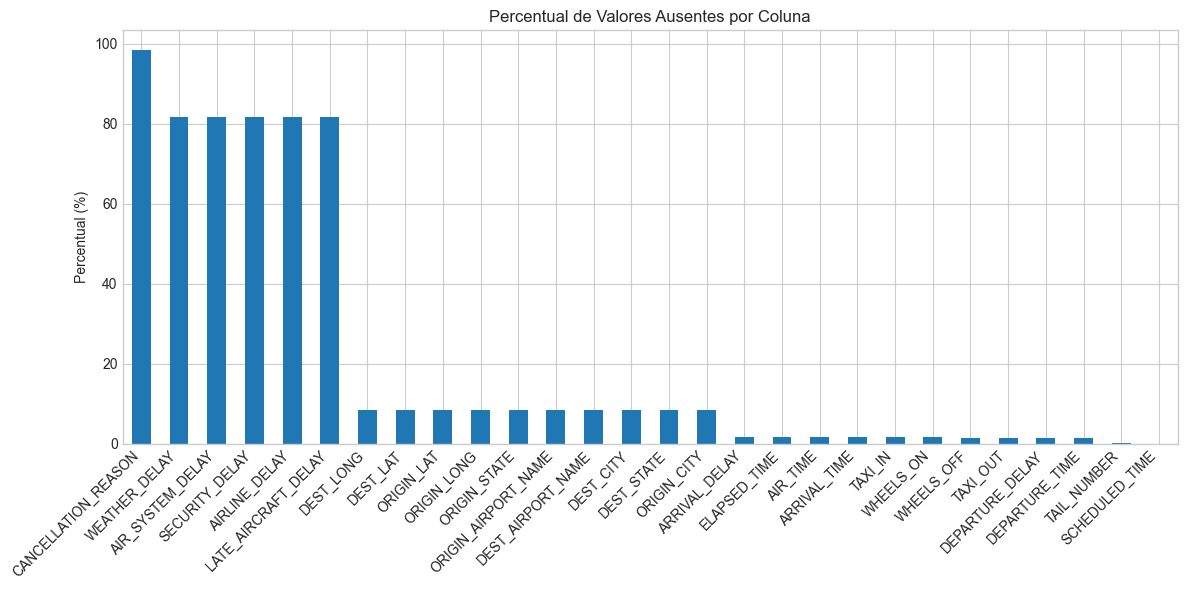

In [9]:
# Visualização de valores ausentes
plt.figure(figsize=(12, 6))
missing_plot = missing_df[missing_df['Percentual (%)'] > 0]['Percentual (%)']
missing_plot.plot(kind='bar')
plt.title('Percentual de Valores Ausentes por Coluna')
plt.ylabel('Percentual (%)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('../reports/figures/missing_values.png', dpi=150)
plt.show()

## 4. Análise da Variável Alvo (Atrasos)

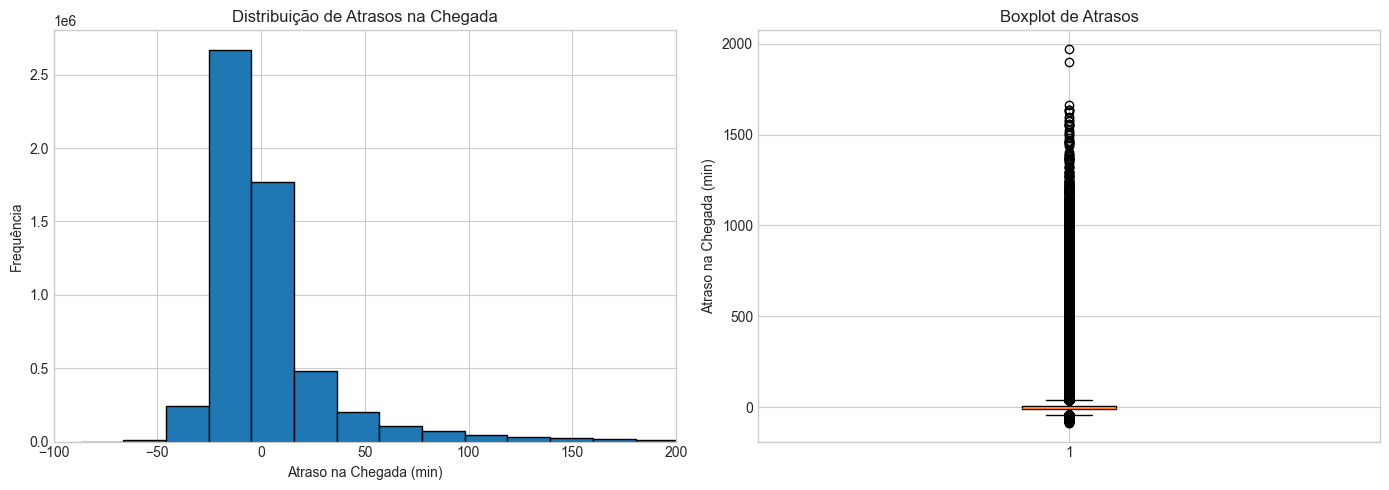

In [10]:
# Distribuição de ARRIVAL_DELAY
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histograma
axes[0].hist(df['ARRIVAL_DELAY'].dropna(), bins=100, edgecolor='black')
axes[0].set_xlabel('Atraso na Chegada (min)')
axes[0].set_ylabel('Frequência')
axes[0].set_title('Distribuição de Atrasos na Chegada')
axes[0].set_xlim(-100, 200)

# Boxplot
axes[1].boxplot(df['ARRIVAL_DELAY'].dropna())
axes[1].set_ylabel('Atraso na Chegada (min)')
axes[1].set_title('Boxplot de Atrasos')

plt.tight_layout()
plt.savefig('../reports/figures/arrival_delay_distribution.png', dpi=150)
plt.show()

Voos no horário: 4,795,581 (82.4%)
Voos atrasados:  1,023,498 (17.6%)


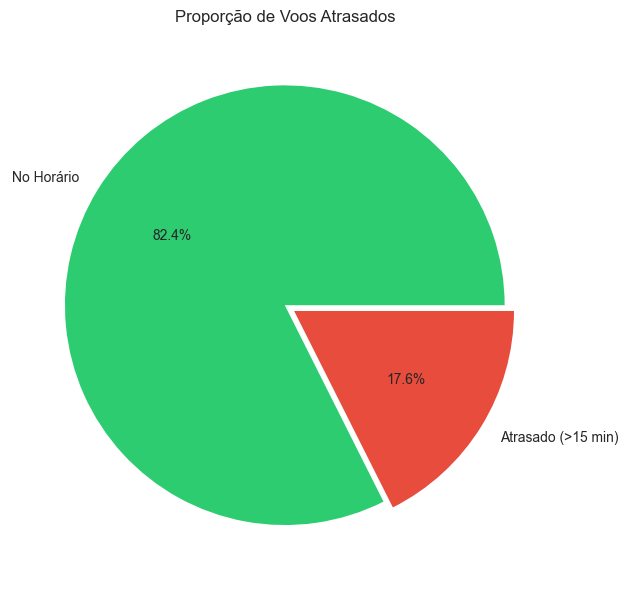

In [11]:
# Criar variável binária de atraso (>15 min)
df['DELAYED'] = (df['ARRIVAL_DELAY'] > 15).astype(int)

# Proporção de voos atrasados
delay_counts = df['DELAYED'].value_counts()
print(f"Voos no horário: {delay_counts[0]:,} ({delay_counts[0]/len(df)*100:.1f}%)")
print(f"Voos atrasados:  {delay_counts[1]:,} ({delay_counts[1]/len(df)*100:.1f}%)")

# Gráfico de pizza
plt.figure(figsize=(8, 6))
plt.pie([delay_counts[0], delay_counts[1]], 
        labels=['No Horário', 'Atrasado (>15 min)'],
        autopct='%1.1f%%',
        colors=['#2ecc71', '#e74c3c'],
        explode=(0, 0.05))
plt.title('Proporção de Voos Atrasados')
plt.tight_layout()
plt.savefig('../reports/figures/delay_proportion.png', dpi=150)
plt.show()

## 5. Análise por Companhia Aérea

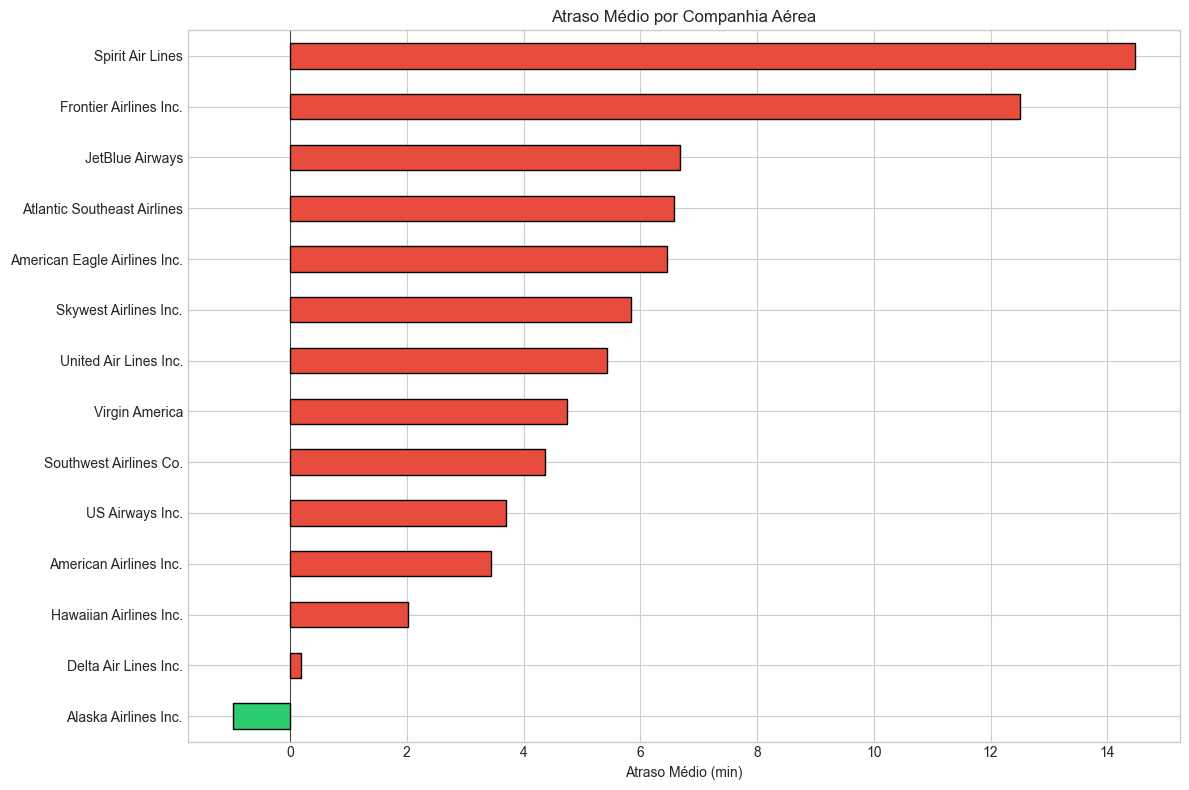

In [12]:
# Atraso médio por companhia (usando nome completo)
airline_delay = df.groupby('AIRLINE_NAME')['ARRIVAL_DELAY'].mean().sort_values(ascending=True)

plt.figure(figsize=(12, 8))
colors = ['#e74c3c' if x > 0 else '#2ecc71' for x in airline_delay.values]
airline_delay.plot(kind='barh', color=colors, edgecolor='black')
plt.title('Atraso Médio por Companhia Aérea')
plt.xlabel('Atraso Médio (min)')
plt.ylabel('')
plt.axvline(x=0, color='black', linestyle='-', linewidth=0.5)
plt.tight_layout()
plt.savefig('../reports/figures/delay_by_airline.png', dpi=150)
plt.show()

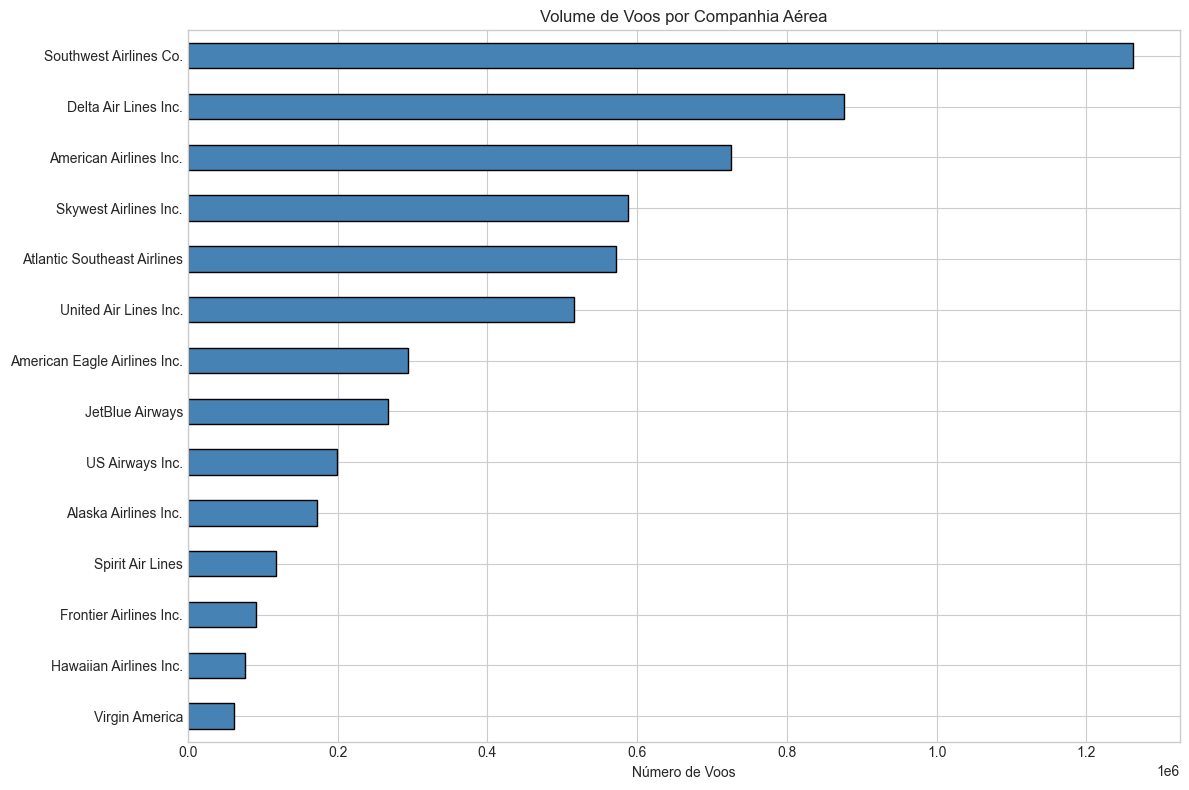

In [13]:
# Volume de voos por companhia
airline_volume = df.groupby('AIRLINE_NAME').size().sort_values(ascending=True)

plt.figure(figsize=(12, 8))
airline_volume.plot(kind='barh', color='steelblue', edgecolor='black')
plt.title('Volume de Voos por Companhia Aérea')
plt.xlabel('Número de Voos')
plt.ylabel('')
plt.tight_layout()
plt.savefig('../reports/figures/volume_by_airline.png', dpi=150)
plt.show()

## 6. Análise Temporal

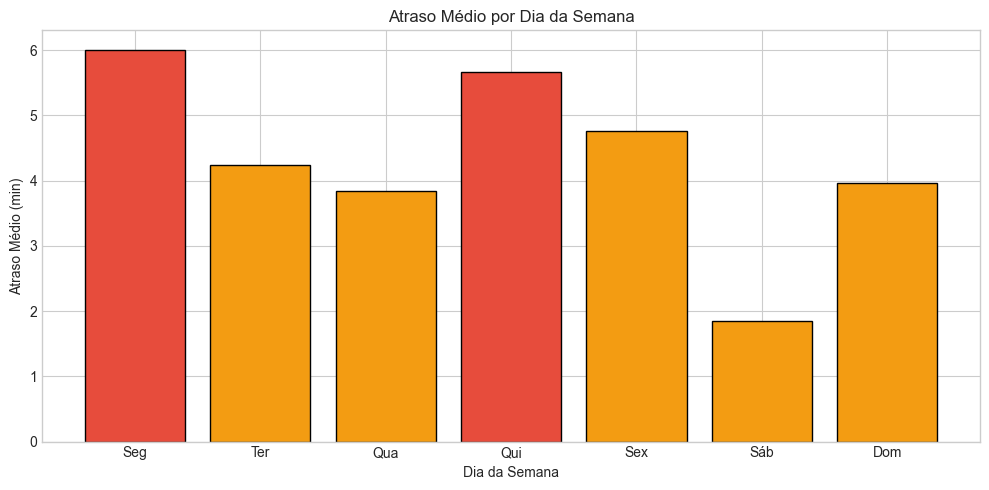

In [14]:
# Atraso por dia da semana
day_names = {1: 'Segunda', 2: 'Terça', 3: 'Quarta', 4: 'Quinta', 5: 'Sexta', 6: 'Sábado', 7: 'Domingo'}
df['DAY_NAME'] = df['DAY_OF_WEEK'].map(day_names)

day_delay = df.groupby('DAY_OF_WEEK')['ARRIVAL_DELAY'].mean()

plt.figure(figsize=(10, 5))
colors = ['#e74c3c' if x > 5 else '#f39c12' if x > 0 else '#2ecc71' for x in day_delay.values]
plt.bar(day_delay.index, day_delay.values, color=colors, edgecolor='black')
plt.xticks(range(1, 8), ['Seg', 'Ter', 'Qua', 'Qui', 'Sex', 'Sáb', 'Dom'])
plt.xlabel('Dia da Semana')
plt.ylabel('Atraso Médio (min)')
plt.title('Atraso Médio por Dia da Semana')
plt.axhline(y=0, color='black', linestyle='-', linewidth=0.5)
plt.tight_layout()
plt.savefig('../reports/figures/delay_by_weekday.png', dpi=150)
plt.show()

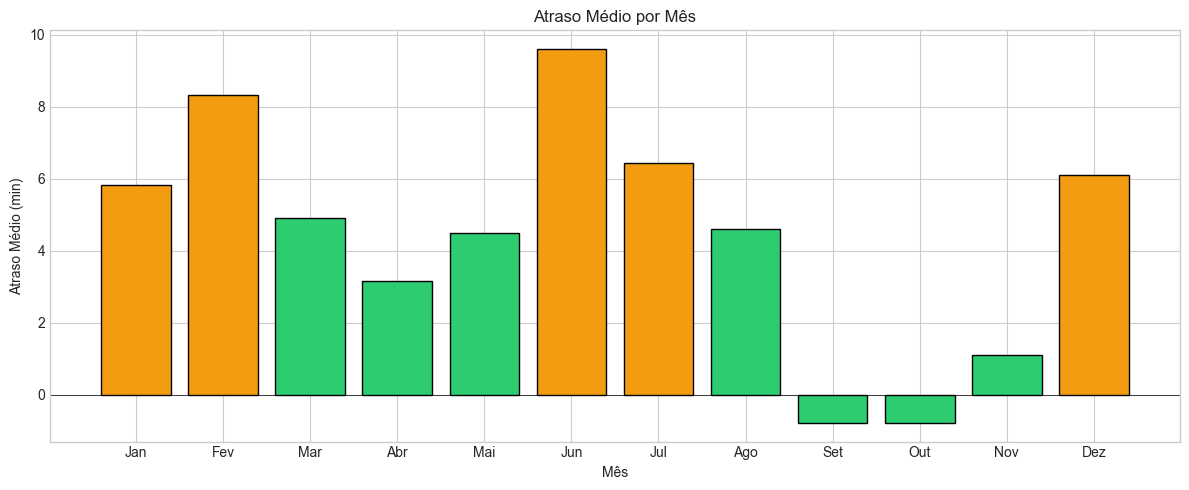

In [15]:
# Atraso por mês
month_delay = df.groupby('MONTH')['ARRIVAL_DELAY'].mean()
month_names = ['Jan', 'Fev', 'Mar', 'Abr', 'Mai', 'Jun', 'Jul', 'Ago', 'Set', 'Out', 'Nov', 'Dez']

plt.figure(figsize=(12, 5))
colors = ['#e74c3c' if x > 10 else '#f39c12' if x > 5 else '#2ecc71' for x in month_delay.values]
plt.bar(month_delay.index, month_delay.values, color=colors, edgecolor='black')
plt.xticks(range(1, 13), month_names)
plt.xlabel('Mês')
plt.ylabel('Atraso Médio (min)')
plt.title('Atraso Médio por Mês')
plt.axhline(y=0, color='black', linestyle='-', linewidth=0.5)
plt.tight_layout()
plt.savefig('../reports/figures/delay_by_month.png', dpi=150)
plt.show()

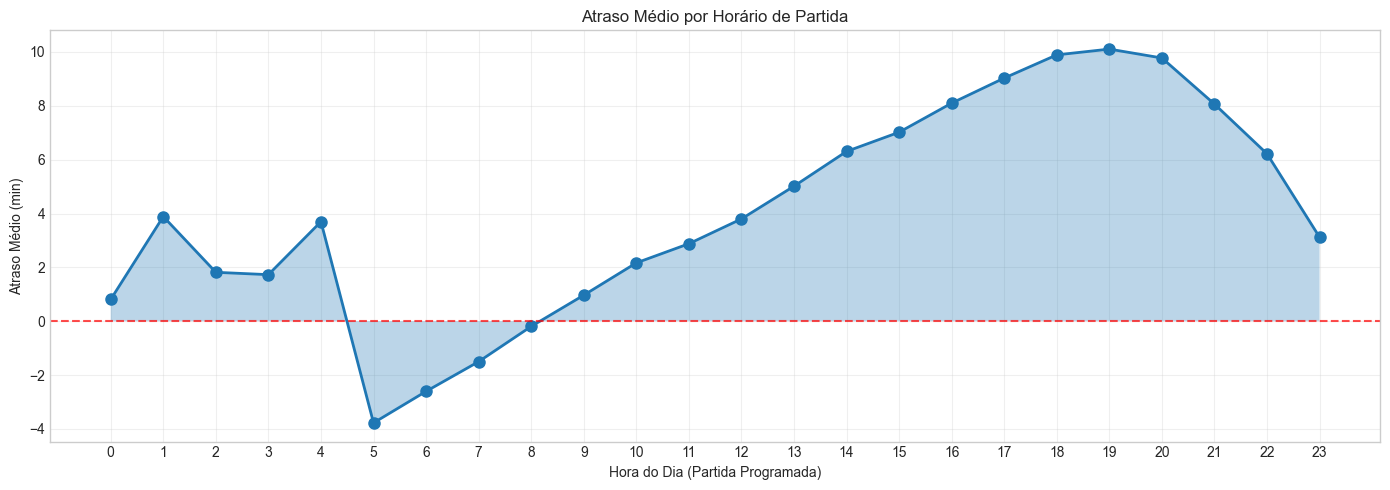

In [16]:
# Atraso por horário do dia
df['HOUR'] = df['SCHEDULED_DEPARTURE'] // 100
hour_delay = df.groupby('HOUR')['ARRIVAL_DELAY'].mean()

plt.figure(figsize=(14, 5))
plt.plot(hour_delay.index, hour_delay.values, marker='o', linewidth=2, markersize=8)
plt.fill_between(hour_delay.index, hour_delay.values, alpha=0.3)
plt.xlabel('Hora do Dia (Partida Programada)')
plt.ylabel('Atraso Médio (min)')
plt.title('Atraso Médio por Horário de Partida')
plt.xticks(range(0, 24))
plt.axhline(y=0, color='red', linestyle='--', alpha=0.7)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('../reports/figures/delay_by_hour.png', dpi=150)
plt.show()

## 7. Análise por Aeroporto

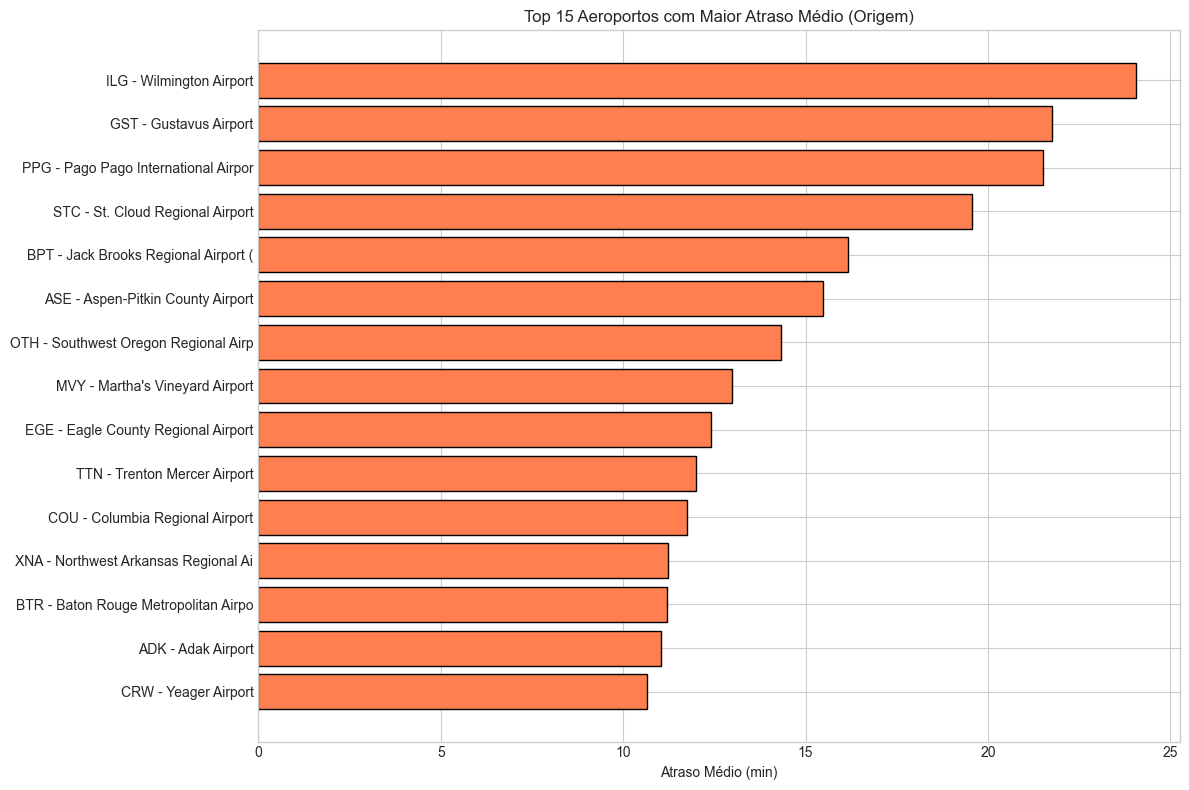

In [17]:
# Top 15 aeroportos com mais atrasos (origem) - usando nome completo
airport_delay = df.groupby(['ORIGIN_AIRPORT', 'ORIGIN_AIRPORT_NAME'])['ARRIVAL_DELAY'].mean()
airport_delay = airport_delay.reset_index()
airport_delay.columns = ['CODE', 'NAME', 'DELAY']
airport_delay['LABEL'] = airport_delay['CODE'] + ' - ' + airport_delay['NAME'].str[:30]
airport_delay = airport_delay.sort_values('DELAY', ascending=False).head(15)

plt.figure(figsize=(12, 8))
plt.barh(airport_delay['LABEL'], airport_delay['DELAY'], color='coral', edgecolor='black')
plt.xlabel('Atraso Médio (min)')
plt.title('Top 15 Aeroportos com Maior Atraso Médio (Origem)')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig('../reports/figures/top_airports_delay.png', dpi=150)
plt.show()

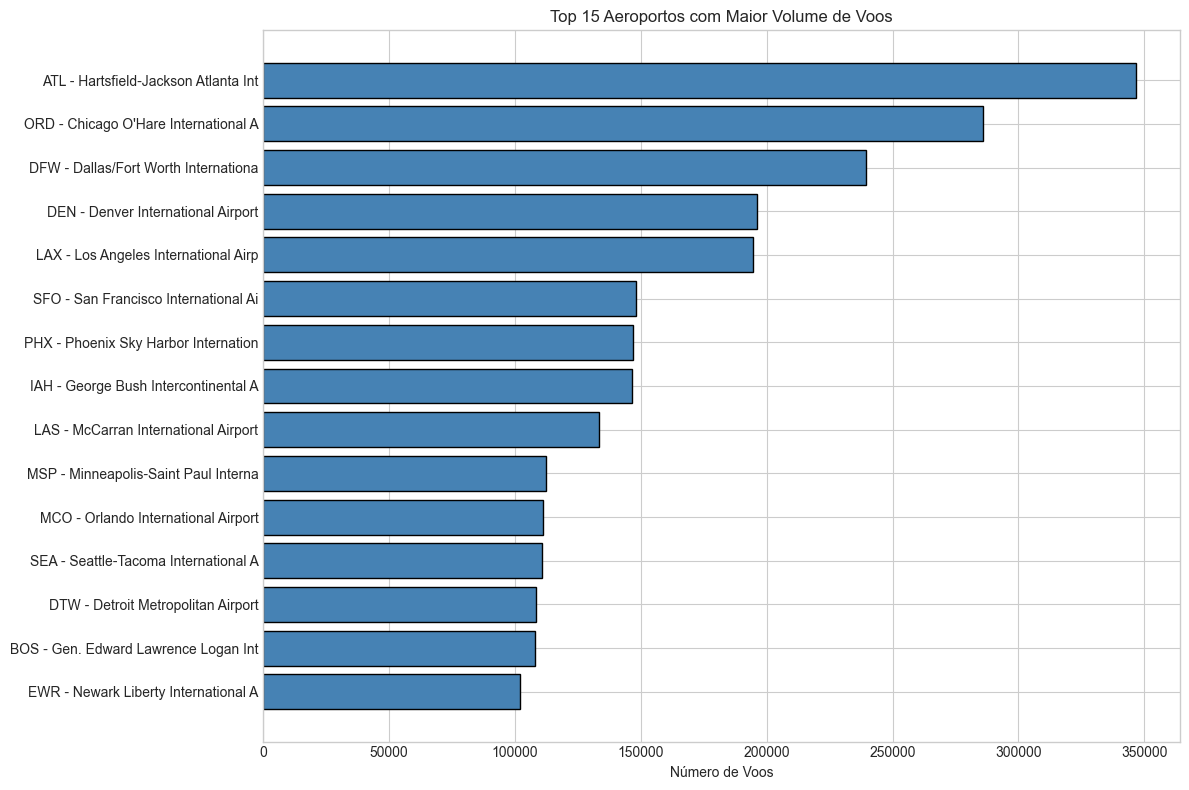

In [18]:
# Aeroportos com mais voos
airport_volume = df.groupby(['ORIGIN_AIRPORT', 'ORIGIN_AIRPORT_NAME']).size()
airport_volume = airport_volume.reset_index()
airport_volume.columns = ['CODE', 'NAME', 'FLIGHTS']
airport_volume['LABEL'] = airport_volume['CODE'] + ' - ' + airport_volume['NAME'].str[:30]
airport_volume = airport_volume.sort_values('FLIGHTS', ascending=False).head(15)

plt.figure(figsize=(12, 8))
plt.barh(airport_volume['LABEL'], airport_volume['FLIGHTS'], color='steelblue', edgecolor='black')
plt.xlabel('Número de Voos')
plt.title('Top 15 Aeroportos com Maior Volume de Voos')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig('../reports/figures/top_airports_volume.png', dpi=150)
plt.show()

## 8. Análise por Estado

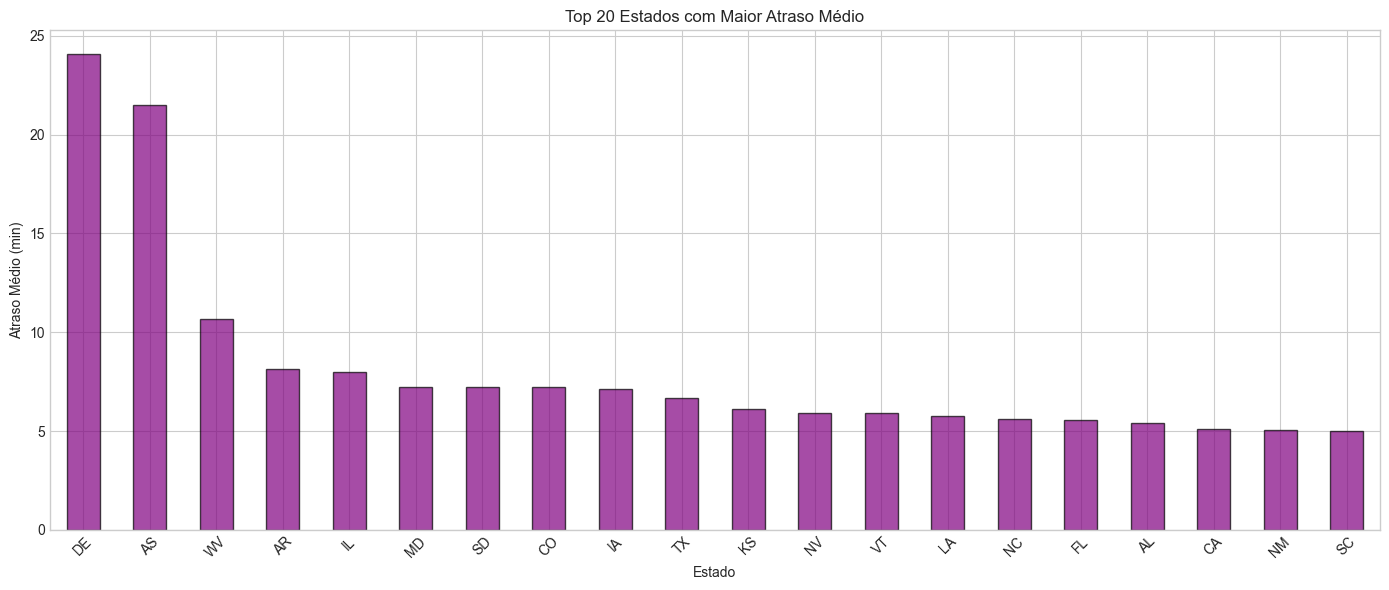

In [19]:
# Atraso médio por estado de origem
state_delay = df.groupby('ORIGIN_STATE')['ARRIVAL_DELAY'].mean().sort_values(ascending=False)

plt.figure(figsize=(14, 6))
state_delay.head(20).plot(kind='bar', color='purple', edgecolor='black', alpha=0.7)
plt.title('Top 20 Estados com Maior Atraso Médio')
plt.xlabel('Estado')
plt.ylabel('Atraso Médio (min)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('../reports/figures/delay_by_state.png', dpi=150)
plt.show()

## 9. Mapa Geográfico de Atrasos

In [20]:
# Agregar dados por aeroporto de origem
airport_stats = df.groupby(['ORIGIN_AIRPORT', 'ORIGIN_AIRPORT_NAME', 'ORIGIN_CITY', 
                            'ORIGIN_STATE', 'ORIGIN_LAT', 'ORIGIN_LONG']).agg({
    'ARRIVAL_DELAY': 'mean',
    'FLIGHT_NUMBER': 'count'
}).reset_index()

airport_stats.columns = ['CODE', 'NAME', 'CITY', 'STATE', 'LAT', 'LONG', 'AVG_DELAY', 'NUM_FLIGHTS']
airport_stats = airport_stats.dropna()

# Filtrar aeroportos com pelo menos 1000 voos
airport_stats = airport_stats[airport_stats['NUM_FLIGHTS'] >= 1000]

print(f'Aeroportos no mapa: {len(airport_stats)}')

Aeroportos no mapa: 224


In [21]:
# Mapa interativo com Plotly
fig = px.scatter_geo(
    airport_stats,
    lat='LAT',
    lon='LONG',
    size='NUM_FLIGHTS',
    color='AVG_DELAY',
    hover_name='NAME',
    hover_data={'CODE': True, 'CITY': True, 'STATE': True, 
                'AVG_DELAY': ':.1f', 'NUM_FLIGHTS': ':,'},
    color_continuous_scale='RdYlGn_r',
    scope='usa',
    title='Mapa de Atrasos por Aeroporto (EUA)',
    labels={'AVG_DELAY': 'Atraso Médio (min)', 'NUM_FLIGHTS': 'Nº Voos'}
)

fig.update_layout(height=600)
fig.write_html('../reports/figures/airport_delay_map.html')
fig.show()

## 10. Análise de Causas de Atraso

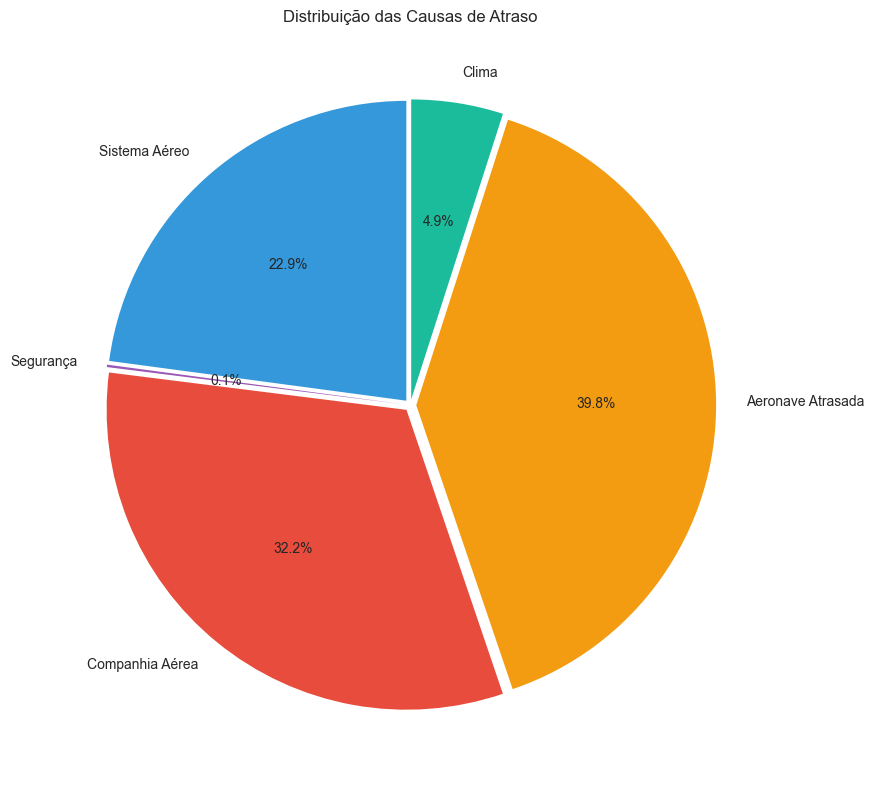

In [22]:
# Causas de atraso
delay_causes = ['AIR_SYSTEM_DELAY', 'SECURITY_DELAY', 'AIRLINE_DELAY', 
                'LATE_AIRCRAFT_DELAY', 'WEATHER_DELAY']

cause_labels = ['Sistema Aéreo', 'Segurança', 'Companhia Aérea', 
                'Aeronave Atrasada', 'Clima']

cause_totals = df[delay_causes].sum()

plt.figure(figsize=(10, 8))
colors = ['#3498db', '#9b59b6', '#e74c3c', '#f39c12', '#1abc9c']
plt.pie(cause_totals.values, labels=cause_labels, autopct='%1.1f%%', 
        startangle=90, colors=colors, explode=(0.02, 0.02, 0.02, 0.02, 0.02))
plt.title('Distribuição das Causas de Atraso')
plt.tight_layout()
plt.savefig('../reports/figures/delay_causes.png', dpi=150)
plt.show()

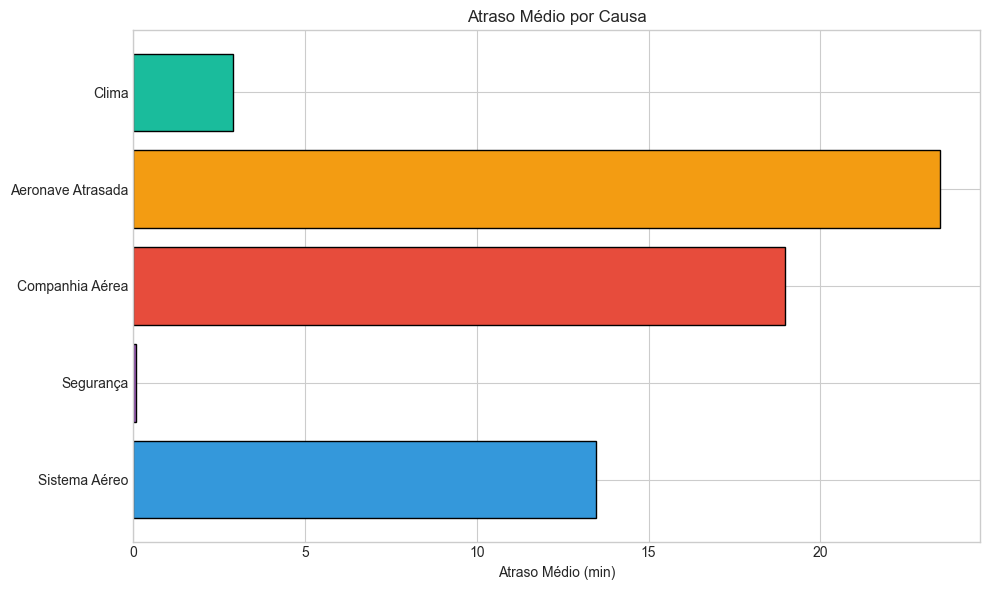

In [23]:
# Média de cada tipo de atraso
cause_means = df[delay_causes].mean()

plt.figure(figsize=(10, 6))
plt.barh(cause_labels, cause_means.values, color=colors, edgecolor='black')
plt.xlabel('Atraso Médio (min)')
plt.title('Atraso Médio por Causa')
plt.tight_layout()
plt.savefig('../reports/figures/delay_causes_mean.png', dpi=150)
plt.show()

## 11. Análise de Cancelamentos

Taxa de cancelamento: 1.54%


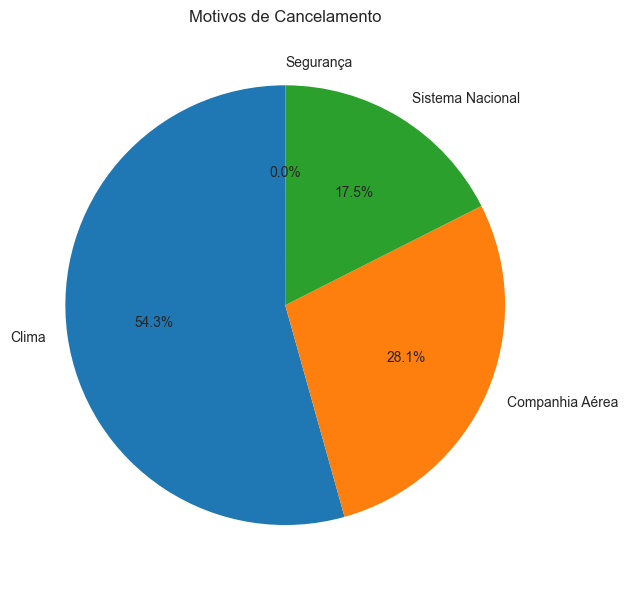

In [24]:
# Taxa de cancelamento
cancel_rate = df['CANCELLED'].mean() * 100
print(f'Taxa de cancelamento: {cancel_rate:.2f}%')

# Motivos de cancelamento
cancel_reasons = df[df['CANCELLED'] == 1]['CANCELLATION_REASON'].value_counts()
reason_labels = {'A': 'Companhia Aérea', 'B': 'Clima', 'C': 'Sistema Nacional', 'D': 'Segurança'}
cancel_reasons.index = cancel_reasons.index.map(reason_labels)

plt.figure(figsize=(10, 6))
cancel_reasons.plot(kind='pie', autopct='%1.1f%%', startangle=90)
plt.title('Motivos de Cancelamento')
plt.ylabel('')
plt.tight_layout()
plt.savefig('../reports/figures/cancellation_reasons.png', dpi=150)
plt.show()

## 12. Matriz de Correlação

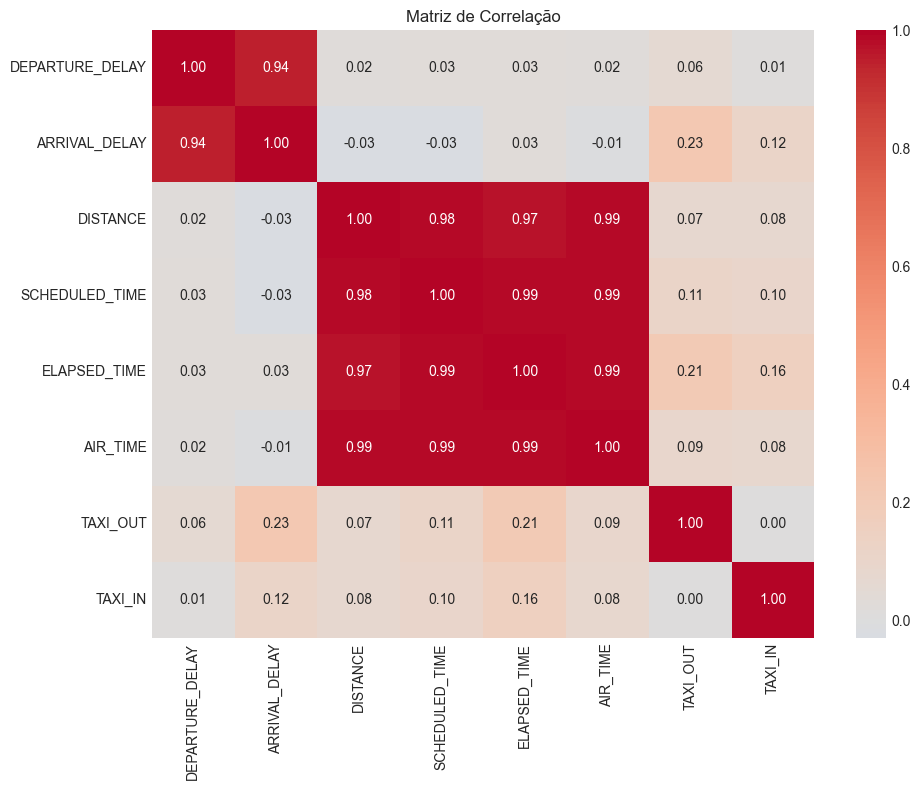

In [25]:
# Selecionar colunas numéricas relevantes
numeric_cols = ['DEPARTURE_DELAY', 'ARRIVAL_DELAY', 'DISTANCE', 'SCHEDULED_TIME',
                'ELAPSED_TIME', 'AIR_TIME', 'TAXI_OUT', 'TAXI_IN']

corr_matrix = df[numeric_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0, fmt='.2f')
plt.title('Matriz de Correlação')
plt.tight_layout()
plt.savefig('../reports/figures/correlation_matrix.png', dpi=150)
plt.show()

## 13. Salvar Dataset Enriquecido

In [26]:
# Salvar dataset com as novas colunas para uso nos próximos notebooks
df.to_csv('../data/processed/flights_enriched.csv', index=False)
print('Dataset enriquecido salvo em data/processed/flights_enriched.csv')
print(f'Shape: {df.shape}')

Dataset enriquecido salvo em data/processed/flights_enriched.csv
Shape: (5819079, 45)


## 14. Conclusões da EDA

### Visão Geral do Dataset
- **Total de voos analisados**: 5.819.079 voos em 2015
- **Taxa de cancelamento**: 1,5% (~90 mil voos)
- **Voos atrasados (>15 min)**: 17,6% do total
- **Atraso médio geral**: 4,4 minutos

### Principais Insights

1. **Companhias Aéreas com Maior Atraso**:
   - Spirit Air Lines: 14,5 min (pior)
   - Frontier Airlines: 12,5 min
   - JetBlue Airways: 6,7 min

2. **Companhias Aéreas com Menor Atraso**:
   - Alaska Airlines: -1,0 min (chegam adiantados em média)
   - Delta Air Lines: 0,2 min
   - Hawaiian Airlines: 2,0 min

3. **Causas de Atraso** (quando há atraso):
   - Aeronave atrasada (efeito cascata): 39,8%
   - Problema da companhia aérea: 32,2%
   - Sistema aéreo (controle de tráfego): 22,9%
   - Clima: 4,9%
   - Segurança: 0,1%

### Padrões Temporais

- **Pior mês**: Junho (9,6 min) - período de férias de verão
- **Melhor mês**: Outubro (-0,8 min) - voos chegam adiantados
- **Pior dia da semana**: Segunda-feira (6,0 min)
- **Melhor dia da semana**: Sábado (1,9 min)
- **Pior horário**: 19h (10,1 min) - acúmulo de atrasos ao longo do dia
- **Melhor horário**: 5h (-3,8 min) - voos da madrugada chegam adiantados

### Aeroportos

- **Maior volume de voos**: ATL (Atlanta), ORD (Chicago), DFW (Dallas)
- Aeroportos menores tendem a ter atrasos mais extremos
- Grandes hubs têm atrasos moderados apesar do alto volume

### Cancelamentos

- Principal motivo: **Clima** (54,3%)
- Companhia aérea: 28,1%
- Sistema Nacional: 17,5%

### Próximos Passos
- Tratar valores ausentes (principalmente colunas de causa de atraso)
- Criar variáveis derivadas (período do dia, estação, fim de semana)
- Preparar dados para modelagem supervisionada e não supervisionada